In [1]:
# (optional) Install required packages
# !pip3 install seaborn
# !pip3 install pandas
# !pip3 install scikit-learn

Import the required libraries

In [2]:
import prepro_pipelines as pp
import model_pipelines as mp

Define the variables

In [3]:
DATA_PATH = "./diabetic_data.csv"
TARGET = "readmitted"
IDENTIFIERS = ["encounter_id", "patient_nbr"]
COLUMNS_TO_DROP = [
        "weight",
        "admission_source_id",
        "payer_code",
        "medical_specialty",
        "repaglinide",
        "nateglinide",
        "chlorpropamide",
        "acetohexamide",
        "tolbutamide",
        "acarbose",
        "miglitol",
        "troglitazone",
        "tolazamide",
        "examide",
        "citoglipton",
        "glyburide-metformin",
        "glipizide-metformin",
        "glimepiride-pioglitazone",
        "metformin-rosiglitazone",
        "metformin-pioglitazone",
    ]

Load the data

In [4]:
data = pp.load_data(DATA_PATH)

=== Loading data from ./diabetic_data.csv ===
Data loaded with shape: (101766, 50)


Preprocess the data

In [5]:
data = (
    # Keep only the first encounter for each patient
    data.pipe(pp.keep_first_encounter)
    # Drop columns with high missing values and unuseful columns
    .pipe(pp.drop_columns, COLUMNS_TO_DROP)
    # Drop rows with invalid gender
    .pipe(pp.drop_row_with_value, "gender", "Unknown/Invalid")
    # Drop rows with expired patients
    .pipe(pp.drop_row_with_value, "admission_type_id", 11)
    .pipe(pp.drop_row_with_value, "admission_type_id", 19)
    .pipe(pp.drop_row_with_value, "admission_type_id", 20)
    .pipe(pp.drop_row_with_value, "admission_type_id", 21)
    # Replace missing values in categorical columns with "None"
    .pipe(pp.replace_missing, "max_glu_serum", "None")
    .pipe(pp.replace_missing, "A1Cresult", "None")
    # Coarse class the diagnosis codes into broader categories
    .pipe(pp.coarse_class_diagnosis, "diag_1")
    .pipe(pp.coarse_class_diagnosis, "diag_2")
    .pipe(pp.coarse_class_diagnosis, "diag_3")
    # Remap unknown race to "Other"
    .pipe(pp.remap_column, "race", {"?": "Other"})
    # Remap medication changes for "Up" and "Down" to "Change"
    .pipe(pp.remap_column, "insulin", {"Up": "Change", "Down": "Change"})
    .pipe(pp.remap_column, "metformin", {"Up": "Change", "Down": "Change"})
    .pipe(pp.remap_column, "glimepiride", {"Up": "Change", "Down": "Change"})
    .pipe(pp.remap_column, "glipizide", {"Up": "Change", "Down": "Change"})
    .pipe(pp.remap_column, "glyburide", {"Up": "Change", "Down": "Change"})
    .pipe(pp.remap_column, "pioglitazone", {"Up": "Change", "Down": "Change"})
    .pipe(pp.remap_column, "rosiglitazone", {"Up": "Change", "Down": "Change"})
    # Group unknown admission types into 0 for "Other", shift 7 ("Trauma Center") to 5 
    .pipe(pp.remap_column, "admission_type_id", {5: 0, 6: 0, 8: 0, 7: 5})
    # Binarize the target variable: 0 for "NO", 1 for "<30" and ">30"
    .pipe(pp.remap_column, "readmitted", {"NO": 0, ">30": 1, "<30": 1})
    # Group unknown discharge types into 0 for "Other", shift values
    .pipe(
        pp.remap_column,
        "discharge_disposition_id",
        {
            18: 0,
            25: 0,
            26: 0,
            12: 11,
            13: 12,
            14: 13,
            15: 14,
            16: 15,
            17: 16,
            22: 17,
            23: 18,
            24: 19,
            30: 20,
            27: 21,
            28: 22,
            29: 23,
        },
    )
)

=== Keeping only the first encounter for each patient ===
Initial shape: (101766, 50), after keeping first encounter: (71518, 50)
=== Dropping columns ===
Remaining columns:
    • encounter_id
    • patient_nbr
    • race
    • gender
    • age
    • admission_type_id
    • discharge_disposition_id
    • time_in_hospital
    • num_lab_procedures
    • num_procedures
    • num_medications
    • number_outpatient
    • number_emergency
    • number_inpatient
    • diag_1
    • diag_2
    • diag_3
    • number_diagnoses
    • max_glu_serum
    • A1Cresult
    • metformin
    • glimepiride
    • glipizide
    • glyburide
    • pioglitazone
    • rosiglitazone
    • insulin
    • change
    • diabetesMed
    • readmitted
=== Dropping rows with value 'Unknown/Invalid' in column: gender ===
Dropped 3 rows with value 'Unknown/Invalid' in column 'gender'
=== Dropping rows with value '11' in column: admission_type_id ===
Dropped 0 rows with value '11' in column 'admission_type_id'
=== Dropping r

/home/weishengtoh/github/5006/Team1_IT5006_Healthcare_Analytics_AY2526/notebooks/milestone2/prepro_pipelines.py:101: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data.replace({column: mapping}, inplace=True)


Save preprocessed data

In [6]:
data.pipe(pp.to_csv, "preprocessed_data.csv")

=== Saving data to preprocessed_data.csv ===
Data saved to preprocessed_data.csv | shape: (71515, 30)


,encounter_id,patient_nbr,race,gender,age,admission_type_id,discharge_disposition_id,time_in_hospital,num_lab_procedures,num_procedures,...,metformin,glimepiride,glipizide,glyburide,pioglitazone,rosiglitazone,insulin,change,diabetesMed,readmitted
0,24437208,135,Caucasian,Female,[50-60),2,1,8,77,6,...,Steady,No,No,Change,No,No,Steady,Ch,Yes,1
1,29758806,378,Caucasian,Female,[50-60),3,1,2,49,1,...,No,No,No,No,No,No,No,No,No,0
2,189899286,729,Caucasian,Female,[80-90),1,3,4,68,2,...,Steady,No,No,No,No,No,No,No,Yes,0
3,64331490,774,Caucasian,Female,[80-90),1,1,3,46,0,...,Steady,No,No,Steady,No,No,No,Ch,Yes,0
4,14824206,927,AfricanAmerican,Female,[30-40),1,1,5,49,0,...,No,Steady,No,No,No,No,No,No,Yes,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
71510,418513058,189351095,Caucasian,Female,[80-90),1,1,1,73,1,...,No,No,No,No,No,No,No,No,No,0
71511,359719064,189365864,Other,Male,[60-70),1,1,3,56,1,...,No,No,No,No,No,No,Steady,No,Yes,0
71512,338462954,189445127,Caucasian,Female,[80-90),1,1,3,39,0,...,Steady,No,Change,No,No,Steady,Change,Ch,Yes,0
71513,443811536,189481478,Caucasian,Female,[40-50),1,4,14,69,0,...,Change,No,No,Steady,No,No,Change,Ch,Yes,1


Preprocess data for the specific model (Gaussian NB)

In [7]:
features = [col for col in data.columns if col not in IDENTIFIERS + [TARGET]]
model, y_test, y_pred = mp.train_gaussian_nb(
    data=data,
    features=features,
    target=TARGET,
    test_size=0.3,
    random_state=42,
)

Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.13      0.22     12895
           1       0.41      0.92      0.57      8560

    accuracy                           0.44     21455
   macro avg       0.56      0.52      0.39     21455
weighted avg       0.59      0.44      0.36     21455



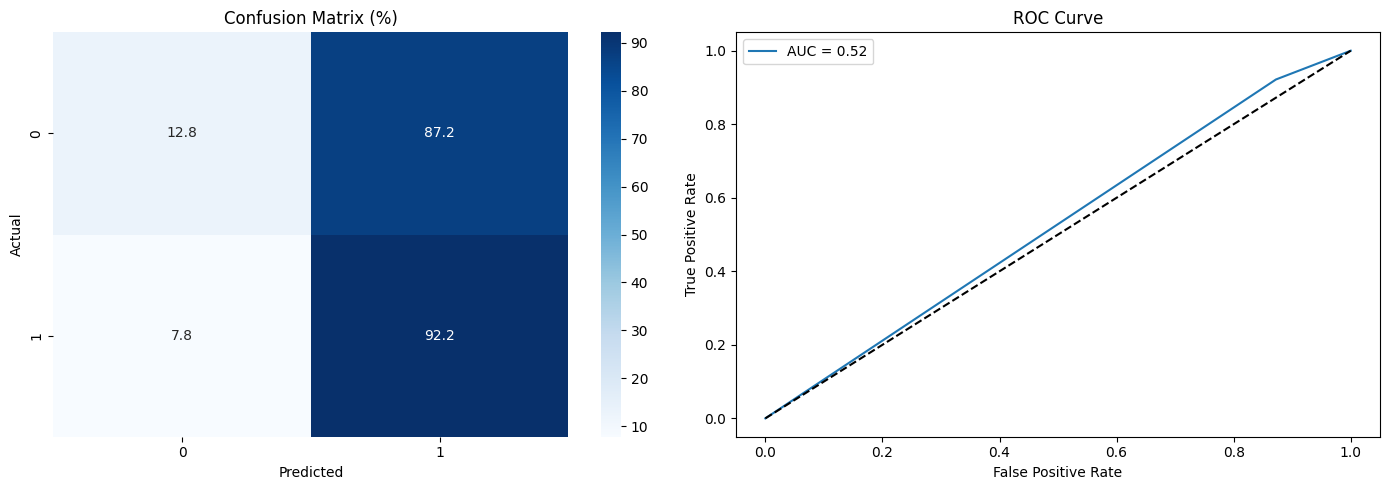


Model Performance Summary:
      Metric     Score
0   Accuracy  0.444558
1  Precision  0.591797
2     Recall  0.444558
3   F1-score  0.357527
4    ROC AUC  0.524765


In [8]:
mp.evaluate_model(y_test, y_pred)